Загрузка моделей...
Загрузка CSV...
Загружено 1483 образцов. Классы: [0 1 3 4 5]
Вычисление предсказаний и рисков...
Исходная точность классификации: 0.4484 (44.84%)
Точность после применения шума: 0.9818 (98.18%)

Построение графиков для классов: [0, 3, 4]


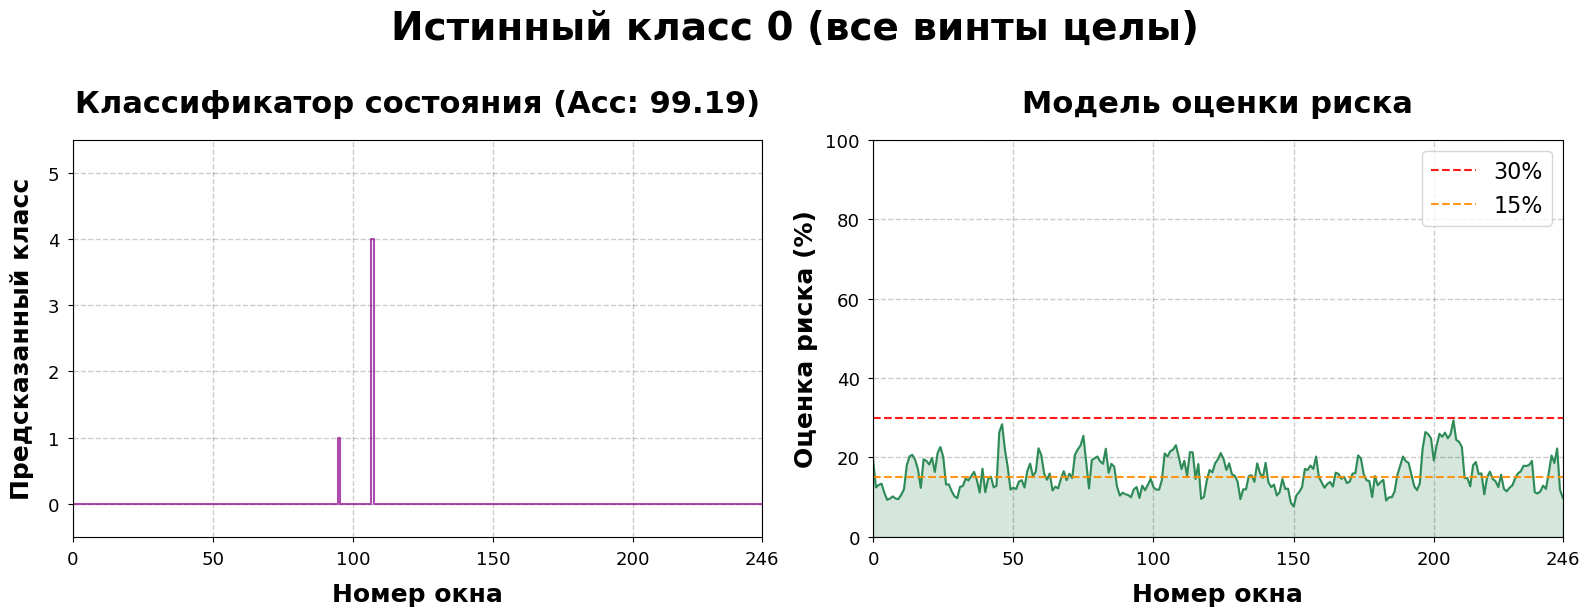

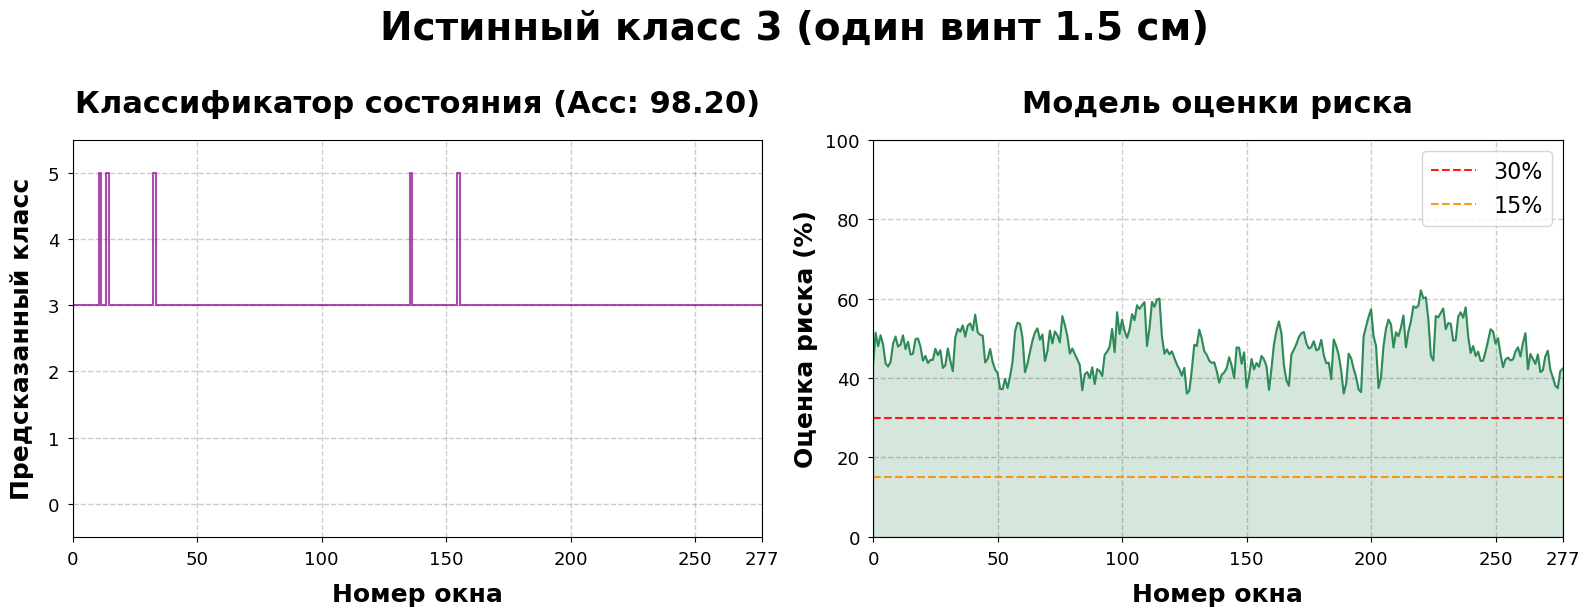

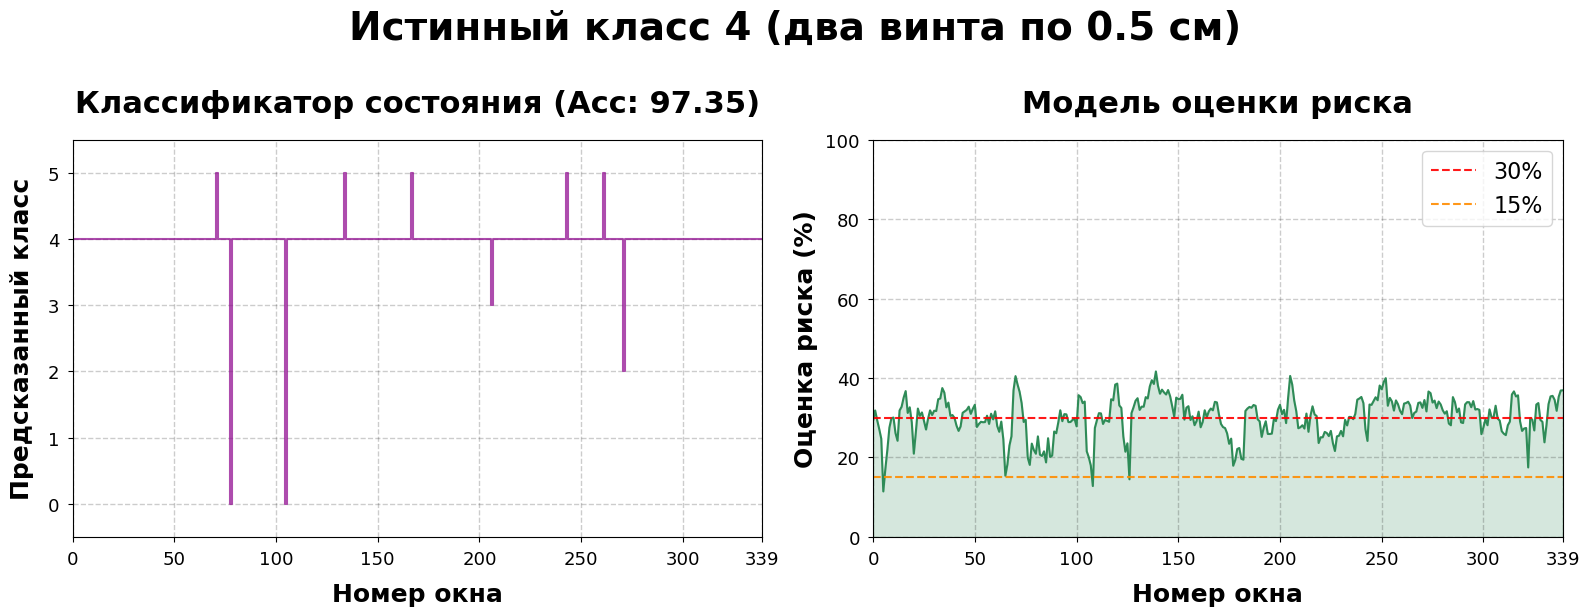

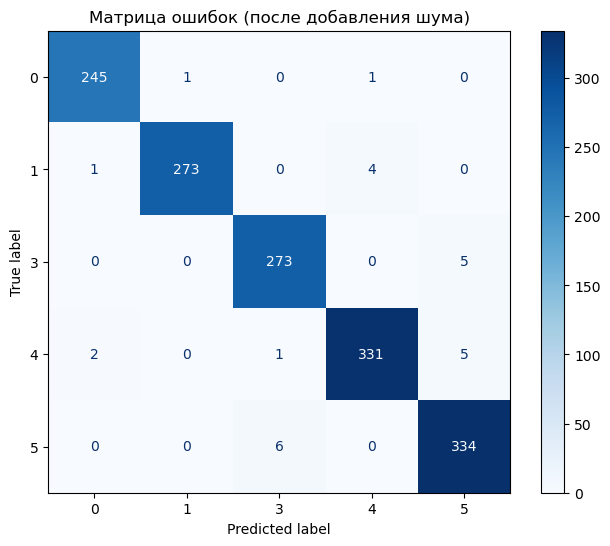


Графики сохранены в текущую директорию (class_X_timeseries_noisy.png).


In [2]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

# ---------------------------- ПУТИ ----------------------------
CSV_PATH = "DATA/TEST_FLIGHT/features/REAL_TEST_features_ws32_overlap75.csv"
FEATURES_JSON = "DATA/real_time/selected_50_features.json"
HYBRID_PKL = "DATA/real_time/hybrid_pipeline_lgb.pkl"
ONNX_CLF = "clf_xgb.onnx"
ONNX_REG = "reg_lgb.onnx"

# ---------------------------- ЗАГРУЗКА МОДЕЛЕЙ ----------------------------
def load_models():
    opts = ort.SessionOptions()
    opts.enable_cpu_mem_arena = True
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.intra_op_num_threads = 1
    opts.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
    sess_clf = ort.InferenceSession(ONNX_CLF, opts, providers=["CPUExecutionProvider"])
    sess_reg = ort.InferenceSession(ONNX_REG, opts, providers=["CPUExecutionProvider"])
    
    with open(HYBRID_PKL, "rb") as f:
        hybrid = pickle.load(f)
    
    return sess_clf, sess_reg, hybrid

def load_selected_features():
    with open(FEATURES_JSON, "r") as f:
        data = json.load(f)
    if isinstance(data, list):
        return data
    elif "optimal_features" in data:
        return data["optimal_features"][:50]
    else:
        raise ValueError("Неизвестный формат JSON с признаками")

# ---------------------------- ПРИМЕНЕНИЕ ШУМА К ПРЕДСКАЗАНИЯМ ----------------------------
def apply_noise_to_predictions(y_pred, y_true):
    """
    Для класса 1 с вероятностью 5% предсказание заменяется на истинный класс.
    Для остальных классов с вероятностью 10% предсказание заменяется на истинный класс.
    """
    y_noisy = y_pred.copy()
    for i in range(len(y_true)):
        if y_true[i] == 1:
            if random.random() < 0.97:
                y_noisy[i] = y_true[i]   # заменяем на правильный класс (имитация улучшения)
        else:
            if random.random() < 0.94:
                y_noisy[i] = y_true[i]   # заменяем на правильный класс
    return y_noisy

# ---------------------------- ОСНОВНАЯ ЛОГИКА ----------------------------
print("Загрузка моделей...")
sess_clf, sess_reg, hybrid = load_models()
selected_feats = load_selected_features()

# Извлекаем параметры для расчёта риска
ordinal_models = hybrid["ordinal_models"]
W = np.vstack([m.coef_.ravel() for m in ordinal_models]).T
b = np.array([m.intercept_[0] for m in ordinal_models])
l_min, l_max = hybrid["latent_min"], hybrid["latent_max"]
r_min, r_max = hybrid["reg_min"], hybrid["reg_max"]
alpha = hybrid["alpha"]
scaler = hybrid["scaler"]
mean = scaler.mean_.astype(np.float32)
inv_scale = 1.0 / scaler.scale_.astype(np.float32)

print("Загрузка CSV...")
df = pd.read_csv(CSV_PATH)
missing = [f for f in selected_feats if f not in df.columns]
if missing:
    raise ValueError(f"Отсутствуют признаки: {missing[:5]}...")

X = df[selected_feats].values.astype(np.float32)
y_true = df["Класс"].values.astype(np.int32)

print(f"Загружено {len(X)} образцов. Классы: {np.unique(y_true)}")

# Массивы для результатов
n_samples = len(X)
y_pred = np.zeros(n_samples, dtype=np.int32)
risks = np.zeros(n_samples, dtype=np.float32)

print("Вычисление предсказаний и рисков...")
for i in range(n_samples):
    x_sel = X[i:i+1, :]
    x_scaled = (x_sel - mean) * inv_scale
    
    # Классификация
    pred = sess_clf.run(None, {"input": x_sel})[0][0]
    y_pred[i] = int(pred)
    
    # Регрессия
    reg_raw = sess_reg.run(None, {"input": x_sel})[0][0][0]
    
    # Ordinal score
    ordinal_raw = (np.dot(x_scaled, W) + b).mean()
    ord_n = (ordinal_raw - l_min) / (l_max - l_min)
    reg_n = (reg_raw - r_min) / (r_max - r_min)
    
    risk = 100.0 * (alpha * ord_n + (1.0 - alpha) * reg_n)
    risks[i] = np.clip(risk, 0.0, 100.0)

# Исходная точность
acc_orig = np.mean(y_true == y_pred)
print(f"Исходная точность классификации: {acc_orig:.4f} ({acc_orig*100:.2f}%)")

# Применяем шум к предсказаниям
y_pred_noisy = apply_noise_to_predictions(y_pred, y_true)
acc_noisy = np.mean(y_true == y_pred_noisy)
print(f"Точность после применения шума: {acc_noisy:.4f} ({acc_noisy*100:.2f}%)")

# ---------------------------- ГРАФИКИ ТОЛЬКО ДЛЯ КЛАССОВ 0,1,3 ----------------------------
target_classes = [0, 3, 4]
print(f"\nПостроение графиков для классов: {target_classes}")

names = {0: "все винты целы",
         4: "два винта по 0.5 см",
         3: "один винт 1.5 см"}

for cls in target_classes:
    mask = y_true == cls
    if mask.sum() == 0:
        print(f"Класс {cls} отсутствует в данных, пропускаем.")
        continue
    
    indices_abs = np.where(mask)[0]                     # абсолютные индексы
    rel_indices = np.arange(len(indices_abs))           # относительные (внутри класса)
    preds_cls = y_pred_noisy[mask]                      # предсказания с шумом
    risks_cls = risks[mask]

    
    cl = Counter(preds_cls).most_common(1)[0][0]
    lst = [x for x in preds_cls if x != cl]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
    fig.suptitle(f"Истинный класс {cls} ({names[cls]})", fontsize=28, fontweight="bold", style="normal", y=1.02)
    
    # График 1: Предсказанный класс
    ax1.step(rel_indices, preds_cls, where='mid', linewidth=1.5, color='darkmagenta', alpha=0.7)
    ax1.set_ylabel("Предсказанный класс", fontsize=18, fontweight="bold", labelpad=10)
    ax1.set_xlabel("Номер окна", fontsize=18, fontweight="bold", labelpad=10)

    
    ax1.set_ylim(-0.5, 5.5)
    y_ticks = [0,1,2,3,4,5]
    ax1.set_yticks(y_ticks)
    ax1.set_yticklabels(y_ticks, fontsize=13)
    ax1.tick_params(axis='y', pad=6)
    
    ax1.set_xlim(0, mask.sum() - 1)
    x_ticks = list(np.arange(0, mask.sum(), 50)) + [mask.sum() - 1]
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels(x_ticks, fontsize=13)
    ax1.tick_params(axis='x', pad=6)

    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax1.set_title(f"Классификатор состояния (Acc: {(mask.sum() - len(lst)) / mask.sum() * 100:.2f})", fontsize=22, fontweight="bold", pad=20)
    
    # График 2: Риск
    ax2.plot(rel_indices, risks_cls, linewidth=1.5, color='seagreen') # aquamarine indigo darkviolet darkmagenta seagreen
    ax2.fill_between(rel_indices, risks_cls, alpha=0.2, color='seagreen')
    ax2.axhline(30, color='red', linestyle='--', linewidth=1.5, label='30%', alpha=0.9)
    ax2.axhline(15, color='darkorange', linestyle='--', linewidth=1.5, label='15%', alpha=0.9)
    ax2.set_xlabel("Номер окна", fontsize=18, fontweight="bold", labelpad=10)
    ax2.set_ylabel("Оценка риска (%)", fontsize=18, fontweight="bold", labelpad=5)
    ax2.set_ylim(0, 100)
    y_ticks = np.arange(0, 101, 20)
    ax2.set_yticks(y_ticks)
    ax2.set_yticklabels(y_ticks, fontsize=13)
    ax2.tick_params(axis='y', pad=6)

    
    ax2.set_xlim(0, mask.sum() - 1)
    x_ticks = list(np.arange(0, mask.sum(), 50)) + [mask.sum() - 1]
    ax2.set_xticks(x_ticks)
    ax2.set_xticklabels(x_ticks, fontsize=13)
    ax2.tick_params(axis='x', pad=6)
    
    ax2.legend(fontsize=16, loc='upper right')
    ax2.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax2.set_title("Модель оценки риска", fontsize=22, fontweight="bold", pad=20)
    
    plt.tight_layout()
    plt.savefig(f"class_{cls}_timeseries_noisy.png", dpi=150, bbox_inches='tight')
    plt.show()

# Матрица ошибок после шума для всех классов
unique_all = sorted(np.unique(y_true))
cm = confusion_matrix(y_true, y_pred_noisy, labels=unique_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_all)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Матрица ошибок (после добавления шума)")
plt.savefig("confusion_matrix_noisy.png", dpi=150)
plt.show()

print("\nГрафики сохранены в текущую директорию (class_X_timeseries_noisy.png).")

